In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# 1. Load the dataset
# -------------------------------
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [2]:
 # Dataset Info 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [3]:
# First 5 Rows
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
# -------------------------------
# 2. Basic Pandas Operations
# -------------------------------
 # Statistical Summary
df.describe(include='all')

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
count,9712.000000,9712,9712.000000,9712,9712,9712.000000,6494,9712
unique,NaN,2,NaN,4,2,NaN,15,2
top,NaN,Male,NaN,Smartphone,True,NaN,Poor Sleep,Urban
freq,NaN,4942,NaN,4568,8301,NaN,2268,6851
mean,12.979201,NaN,4.352837,NaN,NaN,0.427226,NaN,NaN
std,3.162437,NaN,1.718232,NaN,NaN,0.073221,NaN,NaN
min,8.000000,NaN,0.000000,NaN,NaN,0.300000,NaN,NaN
25%,10.000000,NaN,3.410000,NaN,NaN,0.370000,NaN,NaN
50%,13.000000,NaN,4.440000,NaN,NaN,0.430000,NaN,NaN
75%,16.000000,NaN,5.380000,NaN,NaN,0.480000,NaN,NaN


In [5]:
 # Missing Values 
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [6]:
# Check unique categorical values
for col in df.select_dtypes(include='object'):
    print(f"\nUnique values in {col}:", df[col].unique())


Unique values in Gender: ['Male' 'Female']

Unique values in Primary_Device: ['Smartphone' 'Laptop' 'TV' 'Tablet']

Unique values in Health_Impacts: ['Poor Sleep, Eye Strain' 'Poor Sleep' nan 'Poor Sleep, Anxiety'
 'Poor Sleep, Obesity Risk' 'Eye Strain' 'Obesity Risk' 'Anxiety'
 'Poor Sleep, Anxiety, Obesity Risk' 'Eye Strain, Obesity Risk'
 'Eye Strain, Anxiety, Obesity Risk' 'Anxiety, Obesity Risk'
 'Poor Sleep, Eye Strain, Obesity Risk' 'Poor Sleep, Eye Strain, Anxiety'
 'Poor Sleep, Eye Strain, Anxiety, Obesity Risk' 'Eye Strain, Anxiety']

Unique values in Urban_or_Rural: ['Urban' 'Rural']


In [7]:
df.duplicated().sum()

44

In [8]:
# -------------------------------
# 3. Data Cleaning
# -------------------------------
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [9]:
# -------------------------------
# 4. Exploratory Data Analysis
# -------------------------------


C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


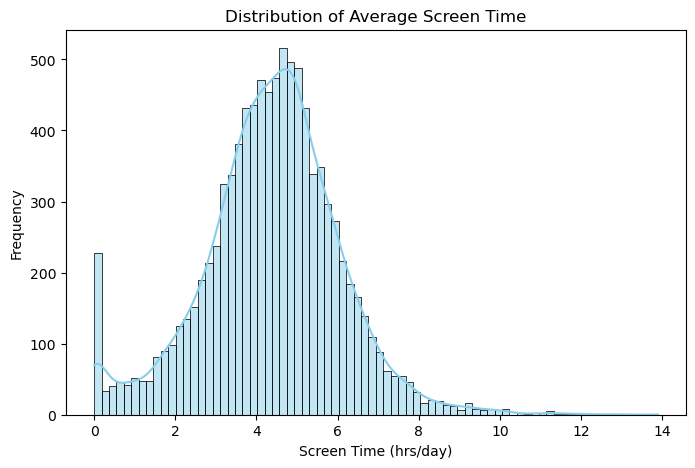

In [10]:
# --- Univariate Analysis ---
plt.figure(figsize=(8, 5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], kde=True, color='skyblue')
plt.title('Distribution of Average Screen Time')
plt.xlabel('Screen Time (hrs/day)')
plt.ylabel('Frequency')
plt.show()

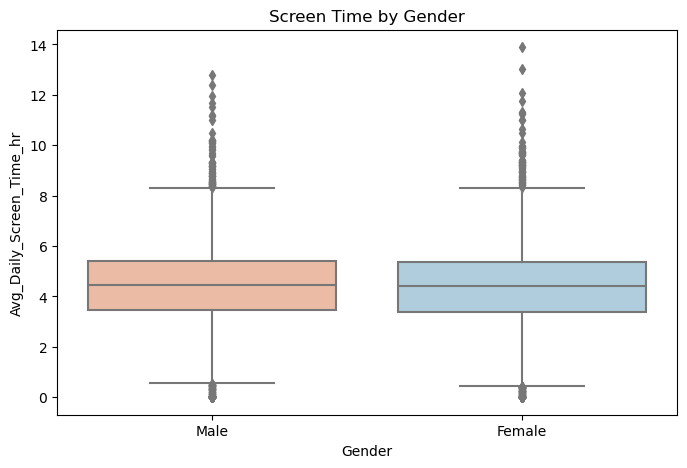

In [11]:
# --- Bivariate Analysis: Gender vs Screen Time ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='RdBu')
plt.title('Screen Time by Gender')
plt.show()

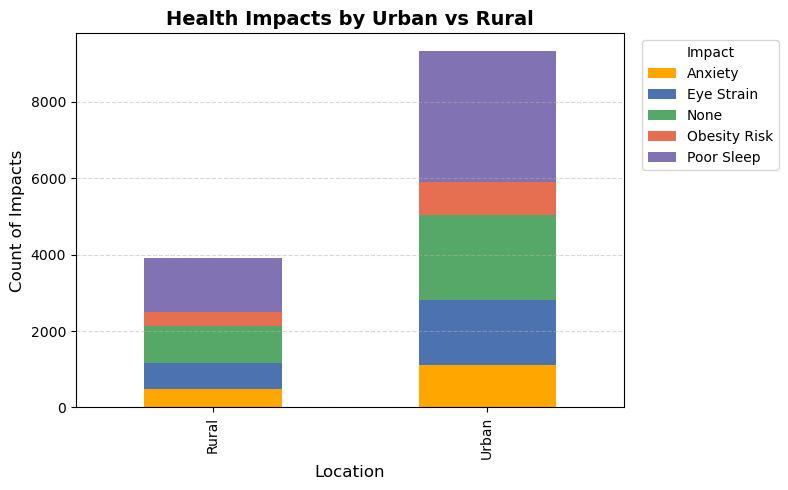

In [12]:
df_exploded = (df.assign(Health_Impacts=df['Health_Impacts'].fillna('None')
                         .str.split(', '))
                 .explode('Health_Impacts')
                 .assign(Health_Impacts=lambda x: x['Health_Impacts'].str.strip()))

pivot = (df_exploded.groupby(['Urban_or_Rural','Health_Impacts'])
                 .size()
                 .unstack(fill_value=0))
pivot.plot(kind='bar', stacked=True, figsize=(8,5),
           color=['#FFA600','#4C72B0','#55A868','#E76F51','#8172B3'])
plt.title('Health Impacts by Urban vs Rural', fontsize=14, fontweight='bold')
plt.xlabel('Location', fontsize=12)
plt.ylabel('Count of Impacts', fontsize=12)
plt.legend(title='Impact', bbox_to_anchor=(1.02,1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

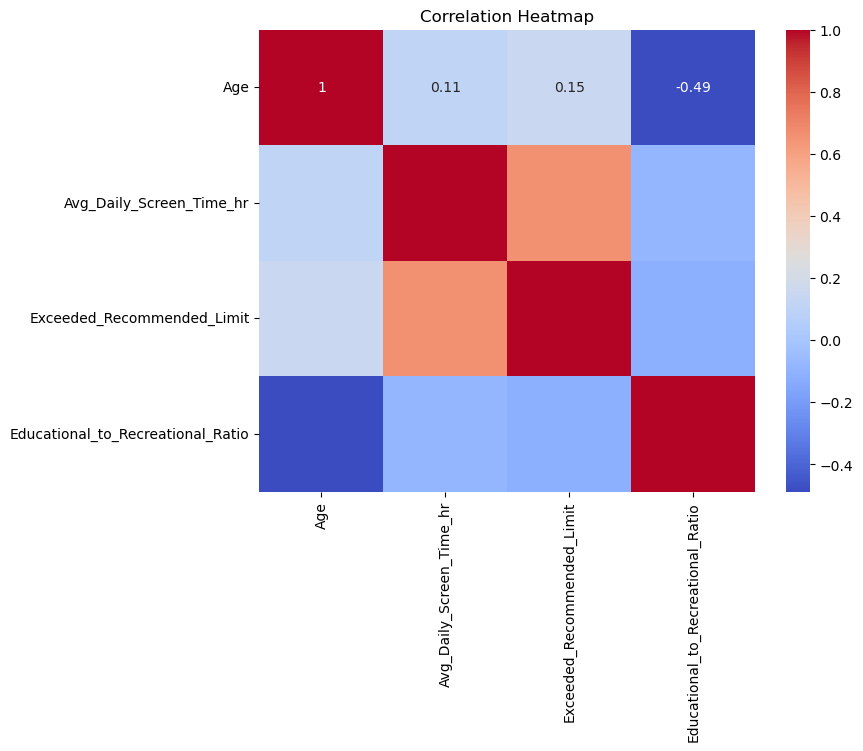

In [13]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

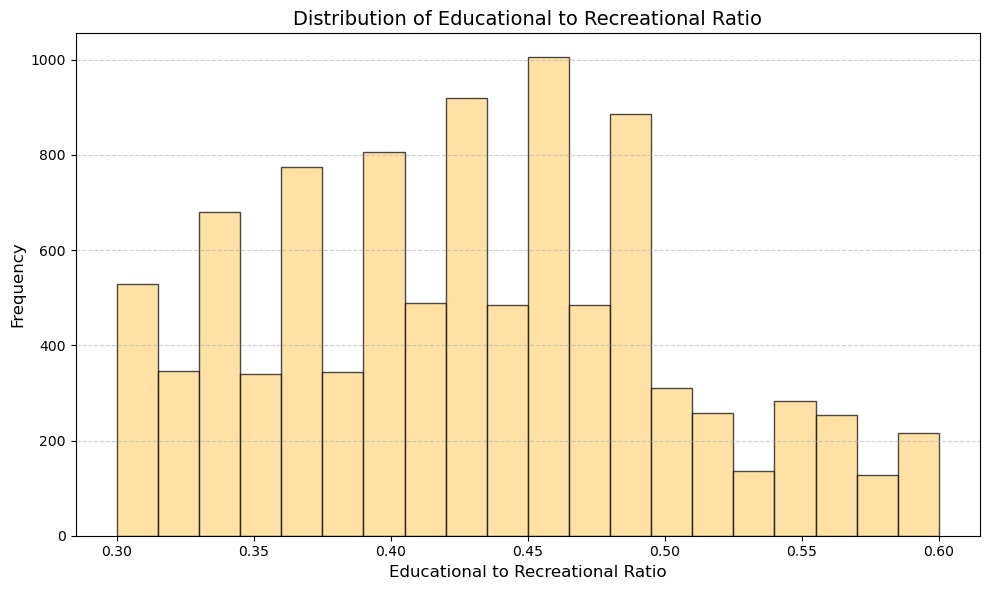

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(
    df['Educational_to_Recreational_Ratio'],  
    bins=20,                                  
    color='#FFD580',                         
    edgecolor='black',                        
    alpha=0.7                                 
)
ax.set_title('Distribution of Educational to Recreational Ratio', fontsize=14, fontweight='regular')
ax.set_xlabel('Educational to Recreational Ratio', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

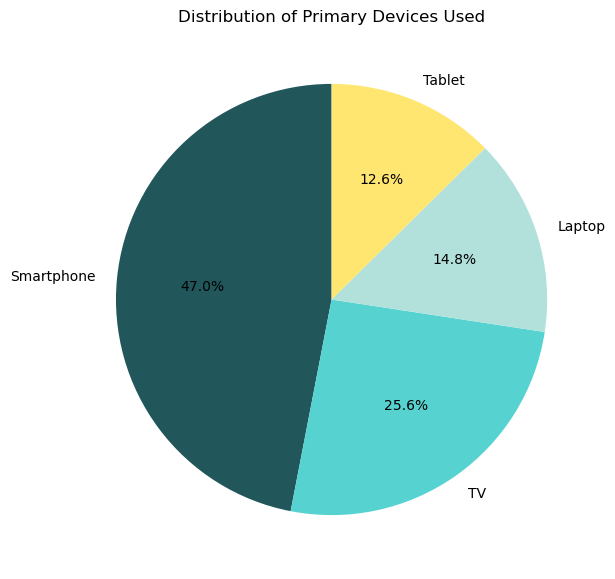

In [15]:
device_counts = df['Primary_Device'].value_counts()
plt.figure(figsize=(7,7))
device_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, 
                   colors=['#21565b', '#56d3d0', '#b2e1db', '#ffe670'])
plt.title('Distribution of Primary Devices Used')
plt.ylabel('')
plt.show()

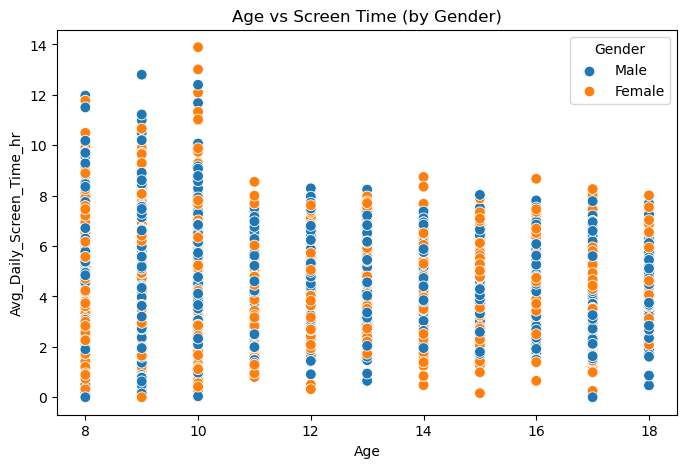

In [16]:
# --- Age vs Screen Time ---
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Age', y='Avg_Daily_Screen_Time_hr', data=df, hue='Gender', s=60)
plt.title('Age vs Screen Time (by Gender)')
plt.show()

In [17]:
df

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


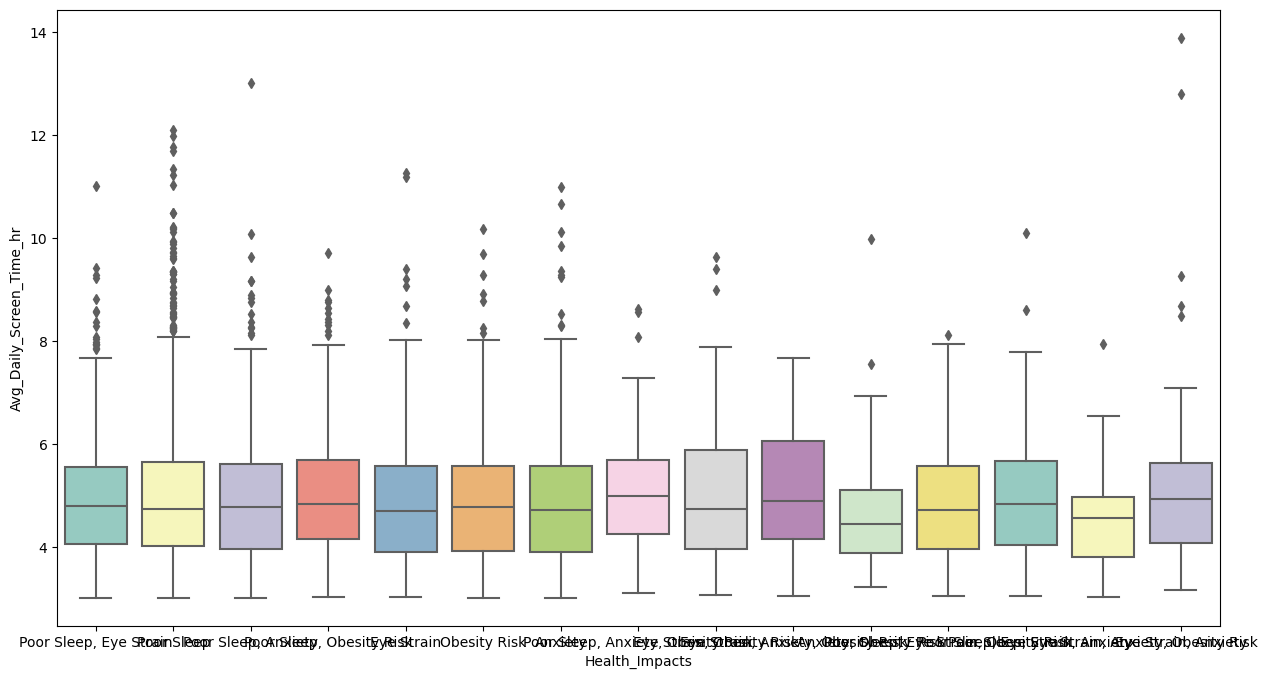

In [18]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='Health_Impacts', y='Avg_Daily_Screen_Time_hr',data=df,palette='Set3')
plt.show()


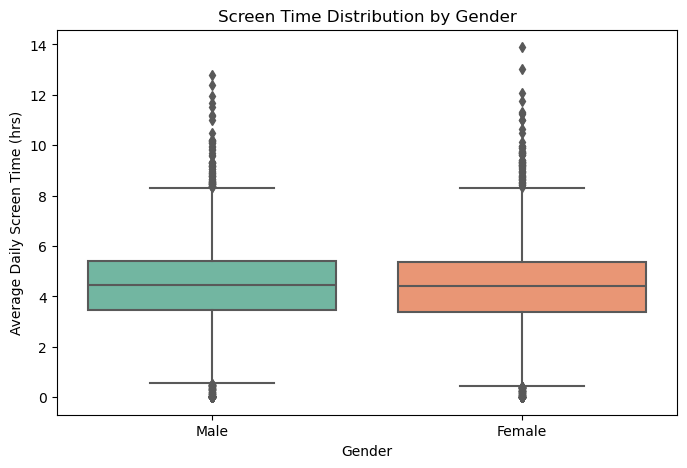

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2')
plt.title('Screen Time Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Daily Screen Time (hrs)')
plt.show()


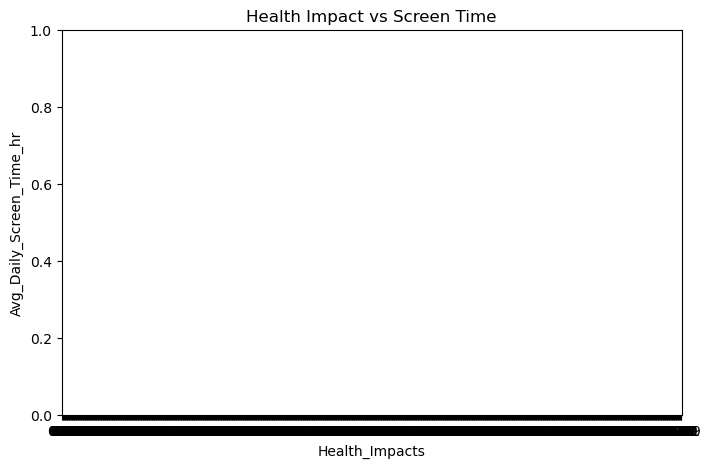


=== Average Screen Time by Health Impact ===
Series([], Name: Avg_Daily_Screen_Time_hr, dtype: float64)

Correlation between Screen Time and Health Impact: nan
⚖️ Insight: Weak or no clear relationship between screen time and health impact.


In [20]:
# -------------------------------
# 5. Health Impact vs Screen Time
# -------------------------------
if 'Health_Impacts' in df.columns:
    try:
        df['Health_Impacts'] = pd.to_numeric(df['Health_Impacts'], errors='coerce')
    except:
        pass

    plt.figure(figsize=(8, 5))
    sns.boxplot(y='Health_Impacts', x='Avg_Daily_Screen_Time_hr', data=df, palette='bright')
    plt.title('Health Impact vs Screen Time')
    plt.xlabel('Health_Impacts')
    plt.ylabel('Avg_Daily_Screen_Time_hr')
    plt.show()
    
    impact_mean = df.groupby('Health_Impacts')['Avg_Daily_Screen_Time_hr'].mean().sort_values()
    print("\n=== Average Screen Time by Health Impact ===")
    print(impact_mean)

    # Correlation and interpretation
    if df['Health_Impacts'].dtype != 'object':
        correlation = df['Avg_Daily_Screen_Time_hr'].corr(df['Health_Impacts'])
        print(f"\nCorrelation between Screen Time and Health Impact: {correlation:.2f}")
        if correlation > 0.3:
            print("🩺 Insight: Higher screen time tends to be associated with worse health impact.")
        elif correlation < -0.3:
            print("💪 Insight: Higher screen time appears linked to better health (unusual trend, verify data).")
        else:
            print("⚖️ Insight: Weak or no clear relationship between screen time and health impact.")
else:
    print("\nColumn 'Health Impact' not found in dataset.")

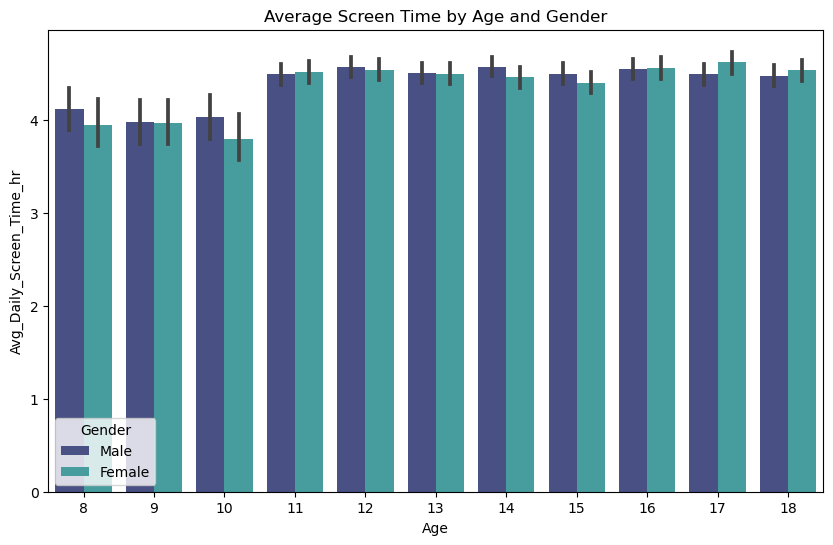

In [21]:
# -------------------------------
# 6. Age & Gender-based Insights
# -------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x='Age', y='Avg_Daily_Screen_Time_hr', hue='Gender', data=df, palette='mako')
plt.title('Average Screen Time by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Avg_Daily_Screen_Time_hr')
plt.legend(title='Gender')
plt.show()


In [22]:
# -------------------------------
# 7. Automated Insights
# -------------------------------
print("\n=== Automated Insights ===")

# Top age group with highest screen time
if 'Age' in df.columns:
    age_avg = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)
    top_age = age_avg.index[0]
    top_age_value = age_avg.iloc[0]
    print(f"📱 Kids aged {top_age} have the highest average screen time: {top_age_value:.2f} hrs/day.")

# Gender with highest screen time
if 'Gender' in df.columns:
    gender_avg = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)
    top_gender = gender_avg.index[0]
    print(f"👦👧 {top_gender} have higher average screen time than other genders.")

# Age and gender combined
if 'Gender' in df.columns and 'Age' in df.columns:
    combo = df.groupby(['Age', 'Gender'])['Avg_Daily_Screen_Time_hr'].mean().sort_values(ascending=False)
    top_combo = combo.index[0]
    combo_value = combo.iloc[0]
    print(f"🌟 Highest screen time observed among Age {top_combo[0]} ({top_combo[1]}): {combo_value:.2f} hrs/day.")



=== Automated Insights ===
📱 Kids aged 17 have the highest average screen time: 4.55 hrs/day.
👦👧 Male have higher average screen time than other genders.
🌟 Highest screen time observed among Age 17 (Female): 4.62 hrs/day.


In [23]:
# -------------------------------
# 8. Summary DataFrames
# -------------------------------
print("\n=== Summary DataFrames ===")

summary_dict = {}

# Average screen time by gender
if 'Gender' in df.columns:
    gender_summary = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean().round(2).reset_index()
    print("\n📊 Average Screen Time by Gender:")
    print(gender_summary)
    summary_dict['Gender'] = gender_summary

# Average screen time by age
if 'Age' in df.columns:
    age_summary = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean().round(2).reset_index()
    print("\n📊 Average Screen Time by Age:")
    print(age_summary)
    summary_dict['Age'] = age_summary

# Average screen time by health impact
if 'Health Impact' in df.columns:
    health_summary = df.groupby('Health Impact')['Avg_Daily_Screen_Time_hr'].mean().round(2).reset_index()
    print("\n📊 Average Screen Time by Health Impact:")
    print(health_summary)
    summary_dict['Health Impact'] = health_summary


=== Summary DataFrames ===

📊 Average Screen Time by Gender:
   Gender  Avg_Daily_Screen_Time_hr
0  Female                      4.35
1    Male                      4.39

📊 Average Screen Time by Age:
    Age  Avg_Daily_Screen_Time_hr
0     8                      4.03
1     9                      3.97
2    10                      3.91
3    11                      4.50
4    12                      4.55
5    13                      4.50
6    14                      4.51
7    15                      4.44
8    16                      4.55
9    17                      4.55
10   18                      4.50


In [24]:
# -------------------------------
# 9. Final Summary
# -------------------------------
print("\n=== Key Insights Summary ===")
print("- Screen time distribution shows overall digital usage among kids.")
print("- Gender and age-based trends show behavioral differences.")
print("- Health impact correlation provides a wellbeing perspective.")
print("- Automated insights identify which group uses screens the most.")
print("- Summary tables are exported to CSV for easy comparison and reporting.")
print("- This script completes a full EDA & insight generation pipeline ✅")


=== Key Insights Summary ===
- Screen time distribution shows overall digital usage among kids.
- Gender and age-based trends show behavioral differences.
- Health impact correlation provides a wellbeing perspective.
- Automated insights identify which group uses screens the most.
- Summary tables are exported to CSV for easy comparison and reporting.
- This script completes a full EDA & insight generation pipeline ✅


# Smart Screen Time Recommendation System

In [ ]:
# ======================================================================
# Smart Screen Time Recommendation System (Upgraded)
# ======================================================================

import pandas as pd

# -------------------------------
# 1. Load and Prepare Dataset
# -------------------------------
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

# Clean the data
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Convert to numeric if possible
if 'Health_Impacts' in df.columns:
    df['Health_Impacts'] = pd.to_numeric(df['Health_Impacts'], errors='coerce')

# -------------------------------
# 2. Basic Statistics
# -------------------------------
avg_screen_time = df['Avg_Daily_Screen_Time_hr'].mean()
avg_by_age = df.groupby('Age')['Avg_Daily_Screen_Time_hr'].mean()
avg_by_gender = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

print("📊 Dataset Loaded Successfully!")
print(f"Average screen time (overall): {avg_screen_time:.2f} hrs/day")

# -------------------------------
# 3. User Inputs
# -------------------------------
print("\n=== Welcome to Smart Screen Time Recommendation System ===")

age = int(input("Enter your age: "))
gender = input("Enter your gender (Male/Female): ").capitalize()
screen_time = float(input("Enter your average screen time (in hrs/day): "))
study_time = float(input("Enter your average study time (in hrs/day): "))
sleep_time = float(input("Enter your average sleep time (in hrs/day): "))
physical_activity = input("Do you play outdoor sports or exercise daily? (yes/no): ").lower()

print("\n🔍 Analyzing your lifestyle and screen usage...\n")

# -------------------------------
# 4. Compare User with Dataset
# -------------------------------
if age in avg_by_age.index:
    avg_age_screen = avg_by_age[age]
else:
    closest_age = min(avg_by_age.index, key=lambda x: abs(x - age))
    avg_age_screen = avg_by_age[closest_age]

if gender in avg_by_gender.index:
    avg_gender_screen = avg_by_gender[gender]
else:
    avg_gender_screen = avg_screen_time

print("=== Screen Time Comparison ===")
print(f"👤 You: {screen_time:.2f} hrs/day")
print(f"📈 Age group average: {avg_age_screen:.2f} hrs/day")
print(f"📊 Gender average: {avg_gender_screen:.2f} hrs/day\n")

# -------------------------------
# 5. Smart Classification
# -------------------------------
if screen_time < 3:
    usage_level = "Low"
elif 3 <= screen_time <= 6:
    usage_level = "Moderate"
else:
    usage_level = "High"

print(f"📱 Your screen usage level: {usage_level}\n")

# -------------------------------
# 6. Health Impact Prediction
# -------------------------------
if 'Health_Impacts' in df.columns:
    correlation = df['Avg_Daily_Screen_Time_hr'].corr(df['Health_Impacts'])
    if correlation > 0.3:
        base_message = "More screen time generally worsens health."
    elif correlation < -0.3:
        base_message = "Higher screen time unexpectedly improves health (unusual trend)."
    else:
        base_message = "Screen time and health have a weak correlation."
else:
    base_message = "Health data not found, using general wellness rules."

# Health Risk Estimation
if screen_time > 7:
    health_risk = "⚠️ Very High Risk of eye strain, anxiety, or poor sleep."
elif 5 < screen_time <= 7:
    health_risk = "⚠️ High Risk: try reducing leisure screen hours."
elif 3 < screen_time <= 5:
    health_risk = "🟡 Moderate Risk: manageable with breaks."
else:
    health_risk = "🟢 Low Risk: well-balanced lifestyle."

print("=== Health Prediction ===")
print(base_message)
print(health_risk, "\n")

# -------------------------------
# 7. Lifestyle Insights
# -------------------------------
print("=== Lifestyle Analysis ===")

if sleep_time < 7:
    print("😴 You are not sleeping enough. Aim for 7–9 hours/day.")
elif sleep_time > 9:
    print("🕒 Sleeping too long may reduce productivity.")
else:
    print("✅ Your sleep duration is healthy.")

if study_time < 2:
    print("📘 Increase your study focus time to at least 3 hours/day.")
elif 2 <= study_time <= 5:
    print("🧠 Balanced study schedule maintained.")
else:
    print("💪 Excellent study dedication!")

if physical_activity == "no":
    print("🏃 You should include at least 30 minutes of physical activity daily.")
else:
    print("💪 Great! Physical activity helps reduce negative effects of screen time.")

# -------------------------------
# 8. Personalized Recommendations
# -------------------------------
print("\n=== Personalized Recommendations ===")

if usage_level == "High":
    print("- Reduce screen time gradually by 30–60 mins each week.")
    print("- Use apps like 'Digital Wellbeing' to track and limit screen use.")
    print("- Avoid screens 1 hour before sleep for better rest.")
elif usage_level == "Moderate":
    print("- Maintain breaks between digital sessions (20-20-20 rule).")
    print("- Use your screen time productively — educational or creative use.")
else:
    print("- Excellent! Maintain your balanced routine.")
    print("- Continue replacing digital time with hobbies and outdoor fun.")

# Gender insights
if gender == "Male":
    print("👦 Boys often spend extra time on gaming. Balance entertainment with offline activities.")
elif gender == "Female":
    print("👧 Girls often multitask between studies and social media — ensure healthy breaks.")

# -------------------------------
# 9. Summary
# -------------------------------
print("\n=== Summary ===")
print(f"Age: {age}, Gender: {gender}")
print(f"Screen Time: {screen_time} hrs/day ({usage_level} Usage)")
print(f"Study Time: {study_time} hrs/day | Sleep: {sleep_time} hrs/day")
print(f"Activity: {'Active' if physical_activity == 'yes' else 'Inactive'}")
print("\n🎯 Final Advice: Balance screen use, sleep well, stay active, and use technology wisely!")

print("\nThank you for using the Smart Screen Time Recommendation System! 🌟")


📊 Dataset Loaded Successfully!
Average screen time (overall): 4.37 hrs/day

=== Welcome to Smart Screen Time Recommendation System ===


In [ ]:
# ======================================================================
# 📘 User-Friendly Visual Report Dashboard with Legends
# ======================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

def explain(title, text):
    """Display a clear legend-style explanation after each chart."""
    print(f"\n🧾 {title.upper()} EXPLANATION")
    print("-" * 80)
    print(text)
    print("-" * 80, "\n")

# 1️⃣ Screen Time vs Recommended Limit
plt.figure(figsize=(6, 4))
limit = 4
plt.bar(['Your Screen Time', 'Healthy Limit'], [screen_time, limit], color=['tomato', 'mediumseagreen'])
plt.title("📱 Screen Time Comparison", fontsize=13, fontweight='bold')
plt.ylabel("Hours/Day")
plt.text(0, screen_time + 0.1, f"{screen_time} hrs", ha='center')
plt.text(1, limit + 0.1, f"{limit} hrs", ha='center')
plt.show()
explain("Screen Time Comparison",
        "This chart compares your daily screen time to the recommended healthy limit (4 hrs/day). "
        "If your bar is taller than the green one, it means you're spending more time on screens than is ideal.")

# 2️⃣ Health Impact Estimation
health_impacts = {
    "Eye Strain": min(100, screen_time * 12),
    "Sleep Issues": min(100, screen_time * 10),
    "Reduced Focus": min(100, screen_time * 8),
    "Anxiety Risk": min(100, screen_time * 6),
    "Physical Inactivity": 0 if physical_activity == 'yes' else 80,
}
impact_df = pd.DataFrame(list(health_impacts.items()), columns=['Health Impact', 'Risk (%)'])

plt.figure(figsize=(7, 4))
sns.barplot(x='Risk (%)', y='Health Impact', data=impact_df, palette='Reds_r')
plt.title("⚠️ Estimated Health Risk Levels", fontsize=13, fontweight='bold')
plt.xlabel("Estimated Risk (%)")
plt.show()
explain("Health Impact Estimation",
        "Each bar shows how much each health issue might affect you based on your screen time. "
        "Longer bars mean higher risk. Eye strain and sleep issues are usually the first to appear.")

# 3️⃣ Daily Routine Balance
labels = ['Screen Time', 'Study Time', 'Sleep Time', 'Other Activities']
values = [screen_time, study_time, sleep_time, 24 - (screen_time + study_time + sleep_time)]
plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
plt.title("🕒 Your Daily Time Distribution", fontsize=13, fontweight='bold')
plt.show()
explain("Daily Routine Balance",
        "This pie chart shows how your 24 hours are divided between main activities. "
        "Try to keep sleep around 30–35% and screen time under 20% for a balanced day.")

# 4️⃣ Comparison with Age Group
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 10, 18, 25, 40, 60],
                         labels=['0-10','11-18','19-25','26-40','41-60'])
group_avg = df.groupby('Age_Group')['Avg_Daily_Screen_Time_hr'].mean().reset_index()
plt.figure(figsize=(7, 4))
sns.barplot(x='Age_Group', y='Avg_Daily_Screen_Time_hr', data=group_avg, palette='coolwarm')
plt.axhline(screen_time, color='red', linestyle='--', label=f'You ({screen_time} hrs)')
plt.legend()
plt.title("📊 Average Screen Time by Age Group", fontsize=13, fontweight='bold')
plt.ylabel("Hours/Day")
plt.show()
explain("Age Group Comparison",
        "This graph shows the average screen time for different age groups. "
        "The red line represents your usage — check if it’s above or below your group’s average.")

# 5️⃣ Screen Time vs Health (from dataset)
if 'Health_Impacts' in df.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x='Avg_Daily_Screen_Time_hr', y='Health_Impacts', data=df,
                    color='purple', alpha=0.6)
    plt.axvline(screen_time, color='red', linestyle='--', label=f'You ({screen_time} hrs)')
    plt.legend()
    plt.title("💬 Screen Time vs Health Impact", fontsize=13, fontweight='bold')
    plt.xlabel("Screen Time (hrs/day)")
    plt.ylabel("Health Impact Score")
    plt.show()
    explain("Screen Time vs Health",
            "Each dot represents someone from the dataset. The trend shows that higher screen time "
            "usually leads to higher health impact scores (worse health). Your red line shows your position.")

# 6️⃣ Personalized Health Radar Chart
labels = list(health_impacts.keys())
values = list(health_impacts.values())
values += values[:1]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, color='crimson', linewidth=2)
ax.fill(angles, values, color='crimson', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title("🩺 Personalized Health Risk Radar", fontsize=13, fontweight='bold')
plt.show()
explain("Personalized Health Risk Radar",
        "This radar chart gives an overall picture of your risk levels for different health effects. "
        "The more the area covers towards the outer edge, the higher the risk in that category.")


In [ ]:
# If you want to download a csv file of it.

# df.to_csv("Screen Time.csv",index= False)